<a href="https://colab.research.google.com/github/hamshini1413/deep-learning/blob/main/1_Vectorized_Multi_Layer_Perceptron_(MLP)_Forward_%26_Backward_Pass_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
# Dataset Parameters
samples = 500
input_size = 4
hidden_size = 8
output_size = 3

# Generate Input Data
X = np.random.randn(samples, input_size)

# Generate Labels
y = np.random.randint(0, output_size, samples)

# One-Hot Encoding
Y = np.eye(output_size)[y]

print("Input Shape :", X.shape)
print("Output Shape:", Y.shape)

Input Shape : (500, 4)
Output Shape: (500, 3)


In [3]:
# Xavier Initialization

W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1/input_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1/hidden_size)
b2 = np.zeros((1, output_size))

learning_rate = 0.05
epochs = 1000

In [4]:
# ReLU

def relu(x):
    return np.maximum(0, x)

# ReLU Derivative

def relu_derivative(x):
    return (x > 0).astype(float)

# Softmax

def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

In [5]:
def cross_entropy(pred, target):
    m = target.shape[0]
    loss = -np.sum(target * np.log(pred + 1e-9)) / m
    return loss

In [6]:
def accuracy(pred, labels):
    prediction = np.argmax(pred, axis=1)
    return np.mean(prediction == labels)

In [7]:
losses = []
accuracies = []

for epoch in range(epochs):

    # Forward Pass
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)

    loss = cross_entropy(A2, Y)

    # Backward Pass
    m = X.shape[0]

    dZ2 = (A2 - Y) / m

    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)

    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Gradient Descent
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    losses.append(loss)
    accuracies.append(accuracy(A2, y))

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1} | Loss = {loss:.4f} | Accuracy = {accuracy(A2,y)*100:.2f}%")

Epoch 100 | Loss = 1.0964 | Accuracy = 38.00%
Epoch 200 | Loss = 1.0881 | Accuracy = 40.00%
Epoch 300 | Loss = 1.0835 | Accuracy = 41.60%
Epoch 400 | Loss = 1.0808 | Accuracy = 42.00%
Epoch 500 | Loss = 1.0790 | Accuracy = 41.60%
Epoch 600 | Loss = 1.0771 | Accuracy = 41.40%
Epoch 700 | Loss = 1.0754 | Accuracy = 41.40%
Epoch 800 | Loss = 1.0739 | Accuracy = 41.80%
Epoch 900 | Loss = 1.0725 | Accuracy = 42.80%
Epoch 1000 | Loss = 1.0714 | Accuracy = 43.20%


In [8]:
print("Training Completed")

prediction = np.argmax(A2, axis=1)

print("Final Accuracy:", accuracy(A2, y) * 100)

Training Completed
Final Accuracy: 43.2


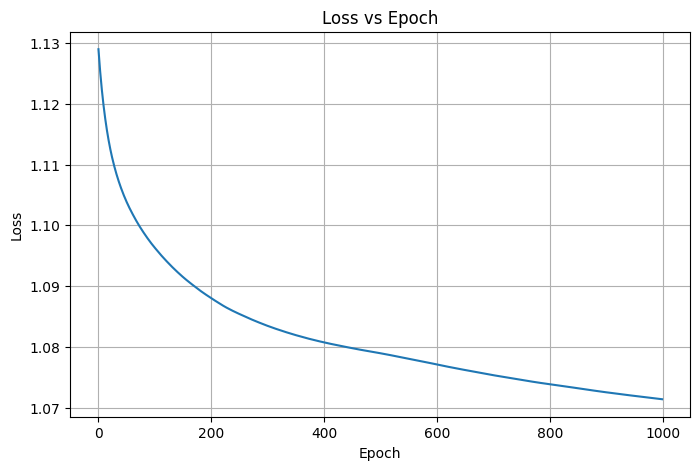

In [9]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

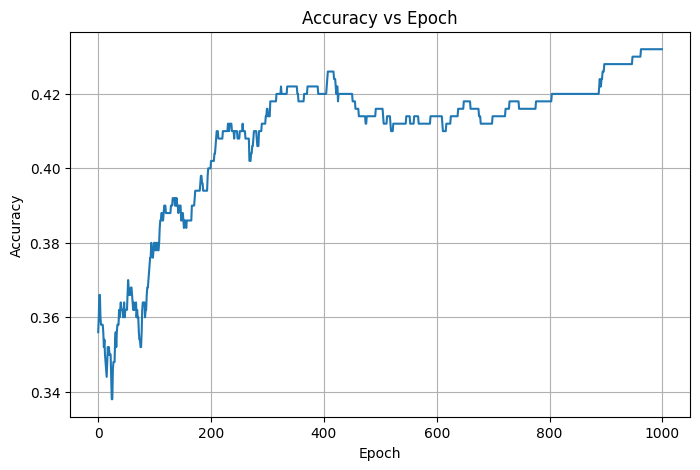

In [10]:
plt.figure(figsize=(8,5))
plt.plot(accuracies)
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()